# Notebook 02 — Feature Engineering
**Project:** Vendor Risk Scorecard & Delivery Delay Root Cause System  
**Input:** `data/processed/orders_clean.csv` (from notebook 01)  
**Output:** `data/processed/vendor_features.csv`

---
### What we do in this notebook

We calculate 8 features per vendor:

| Feature | What it measures |
|---|---|
| `total_orders` | Volume — how many orders this seller fulfills |
| `otd_rate` | On-Time Delivery rate — % of orders delivered on or before estimated date |
| `late_rate` | Inverse of OTD — % of orders that are late |
| `avg_processing_days` | Average seller processing time |
| `p75_processing_days` | 75th percentile processing time — catches sellers who are slow on some orders |
| `avg_carrier_days` | Average carrier delivery time for this seller's orders |
| `avg_delay_days` | Average days late (positive = late, negative = early) |
| `sla_breach_rate` | % of orders where delay > 3 days — a stricter measure than just 'late' |

**Why these features?**  
OTD rate alone is too simple. A seller with 85% OTD might still have occasional extreme delays.  
The P75 processing time catches that — it's the 'worst quarter' of their performance.  
SLA breach rate (>3 days late) separates slightly late from seriously late.

---
## Cell 1 — Mount Drive and load clean data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)

BASE    = '/content/drive/MyDrive/vendor-risk-scorecard/'
PROC    = BASE + 'data/processed/'
OUTPUTS = BASE + 'outputs/'

df = pd.read_csv(PROC + 'orders_clean.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print(f'Loaded orders_clean.csv — {df.shape[0]:,} rows')
print(f'Columns: {df.columns.tolist()}')

Mounted at /content/drive
Loaded orders_clean.csv — 96,469 rows
Columns: ['order_id', 'customer_id', 'seller_id', 'order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'seller_processing_days', 'carrier_delivery_days', 'delay_days', 'is_late', 'price', 'seller_state', 'seller_zip_code_prefix', 'customer_state', 'customer_zip_code_prefix']


---
## Cell 2 — Applying minimum order threshold

Sellers with very few orders give unreliable metrics.  
A seller with 2 orders and both late = 100% late rate, but that's not statistically meaningful.  
We keep only sellers with **≥ 10 orders** (you found 1,227 such sellers in notebook 01).

In [2]:
MIN_ORDERS = 10

# Count orders per seller
order_counts = df.groupby('seller_id')['order_id'].count()
eligible_sellers = order_counts[order_counts >= MIN_ORDERS].index

df_filtered = df[df['seller_id'].isin(eligible_sellers)].copy()

print(f'Total unique sellers:    {df["seller_id"].nunique():,}')
print(f'Eligible sellers (≥{MIN_ORDERS}): {len(eligible_sellers):,}')
print(f'Orders from eligible:    {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}% of total orders)')

Total unique sellers:    2,960
Eligible sellers (≥10): 1,226
Orders from eligible:    90,511 (93.8% of total orders)


---
## Cell 3 — Calculating the SLA breach flag

A delay of 1 hour technically makes an order "late" but that's not serious.  
We define **SLA breach** as being more than 3 days late — a meaningful failure.

In [3]:
SLA_THRESHOLD = 3  # days

df_filtered['sla_breach'] = df_filtered['delay_days'] > SLA_THRESHOLD

sla_count = df_filtered['sla_breach'].sum()
print(f'SLA breaches (>{SLA_THRESHOLD} days late): {sla_count:,} orders ({sla_count/len(df_filtered)*100:.1f}%)')
print(f'Simple late (>0 days):        {df_filtered["is_late"].sum():,} orders ({df_filtered["is_late"].mean()*100:.1f}%)')
print()
print('This gap tells us how many "late" orders are only slightly late vs seriously late.')

SLA breaches (>3 days late): 4,847 orders (5.4%)
Simple late (>0 days):        7,316 orders (8.1%)

This gap tells us how many "late" orders are only slightly late vs seriously late.


---
## Cell 4 — Aggregating to vendor level

This is the core transformation of the notebook.  
We go from ~90K order rows → 1,227 vendor rows.

In [4]:
vendor_features = (
    df_filtered
    .groupby('seller_id')
    .agg(
        # Volume
        total_orders          = ('order_id',              'count'),

        # On-time delivery
        otd_rate              = ('is_late',               lambda x: 1 - x.mean()),  # % on time
        late_rate             = ('is_late',               'mean'),                   # % late

        # Seller processing time
        avg_processing_days   = ('seller_processing_days','mean'),
        p75_processing_days   = ('seller_processing_days', lambda x: x.quantile(0.75)),
        median_processing_days= ('seller_processing_days','median'),

        # Carrier delivery time
        avg_carrier_days      = ('carrier_delivery_days', 'mean'),

        # Delay metrics
        avg_delay_days        = ('delay_days',            'mean'),
        sla_breach_rate       = ('sla_breach',            'mean'),  # % with >3d delay

        # Geographic context
        seller_state          = ('seller_state',          'first'),
    )
    .reset_index()
)

# Round all float columns to 4 decimal places
float_cols = vendor_features.select_dtypes(include='float64').columns
vendor_features[float_cols] = vendor_features[float_cols].round(4)

print(f'Vendor features table: {vendor_features.shape[0]:,} vendors × {vendor_features.shape[1]} features')
print()
vendor_features.head(5)

Vendor features table: 1,226 vendors × 11 features



,seller_id,total_orders,otd_rate,late_rate,avg_processing_days,p75_processing_days,median_processing_days,avg_carrier_days,avg_delay_days,sla_breach_rate,seller_state
0,001cca7ae9ae17fb1caed9dfb1094831,194,0.9330,0.0670,2.6007,3.5535,2.1046,10.8328,-12.1569,0.0412,ES
1,002100f778ceb8431b7a1020ff7ab48f,49,0.8163,0.1837,4.4712,5.1645,3.3427,12.0367,-7.2102,0.1429,SP
2,004c9cd9d87a3c30c522c48c4fc07416,155,0.9161,0.0839,1.7541,2.2808,1.3836,13.1211,-11.0375,0.0645,SP
3,00720abe85ba0859807595bbf045a33b,13,0.8462,0.1538,3.6641,4.2794,3.9434,8.1227,-7.0762,0.1538,SP
4,00ee68308b45bc5e2660cd833c3f81cc,133,0.9098,0.0902,1.9605,2.4534,1.5065,7.7424,-10.0349,0.0526,SP


---
## Cell 5 — Understanding the feature distributions

In [5]:
print('Vendor feature statistics:')
print(vendor_features[[
    'total_orders', 'otd_rate', 'late_rate',
    'avg_processing_days', 'p75_processing_days',
    'avg_delay_days', 'sla_breach_rate'
]].describe().round(3).to_string())

Vendor feature statistics:
       total_orders  otd_rate  late_rate  avg_processing_days  p75_processing_days  avg_delay_days  sla_breach_rate
count      1226.000  1226.000   1226.000             1226.000             1226.000        1226.000         1226.000
mean         73.826     0.920      0.080                3.224                4.204         -11.454            0.052
std         153.000     0.072      0.072                2.170                3.013           3.689            0.057
min          10.000     0.357      0.000                0.453                0.716         -42.958            0.000
25%          16.000     0.889      0.030                1.900                2.576         -13.312            0.000
50%          30.000     0.931      0.069                2.576                3.321         -11.050            0.041
75%          68.000     0.970      0.111                3.801                4.967          -9.277            0.077
max        1809.000     1.000      0.643     

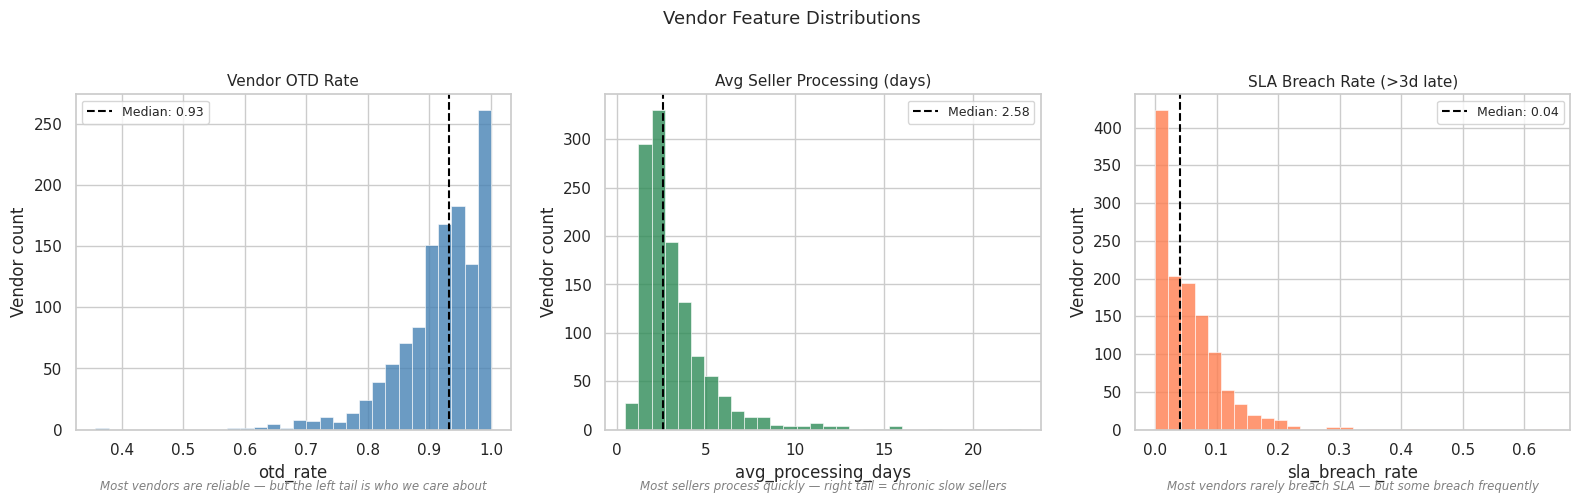

Saved


In [6]:
# Distribution of OTD rates across vendors
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plots = [
    ('otd_rate',           'Vendor OTD Rate',            'steelblue',  'Most vendors are reliable — but the left tail is who we care about'),
    ('avg_processing_days','Avg Seller Processing (days)','seagreen',   'Most sellers process quickly — right tail = chronic slow sellers'),
    ('sla_breach_rate',    'SLA Breach Rate (>3d late)',  'coral',      'Most vendors rarely breach SLA — but some breach frequently'),
]

for ax, (col, title, color, insight) in zip(axes, plots):
    data = vendor_features[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='black', linestyle='--', lw=1.5,
               label=f'Median: {data.median():.2f}')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Vendor count')
    ax.legend(fontsize=9)
    ax.text(0.5, -0.18, insight, transform=ax.transAxes,
            ha='center', fontsize=8.5, color='gray', style='italic')

plt.suptitle('Vendor Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS + '02_vendor_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

---
## Cell 6 — Correlation between features

Before scoring, check if any features are redundant (highly correlated).  
If two features measure almost the same thing, one of them adds little to the scorecard.

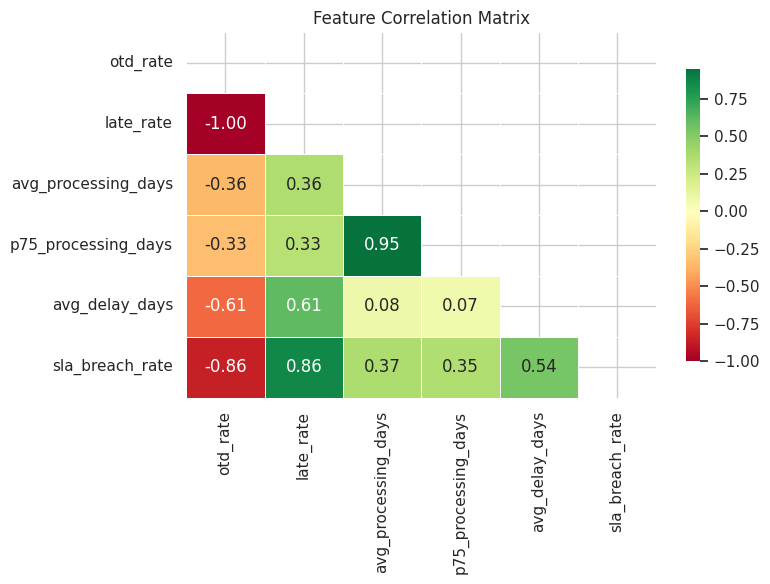

Saved


In [7]:
score_features = [
    'otd_rate', 'late_rate', 'avg_processing_days',
    'p75_processing_days', 'avg_delay_days', 'sla_breach_rate'
]

corr = vendor_features[score_features].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS + '02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

In [8]:
# Print the strong correlations — r > 0.7 means features are very similar
print('Strong correlations (|r| > 0.7):')
found = False
for i in range(len(score_features)):
    for j in range(i+1, len(score_features)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {score_features[i]:30s} vs {score_features[j]:30s}  r = {r:.2f}')
            found = True
if not found:
    print('  None — all features contribute independent signal')

Strong correlations (|r| > 0.7):
  otd_rate                       vs late_rate                       r = -1.00
  otd_rate                       vs sla_breach_rate                 r = -0.86
  late_rate                      vs sla_breach_rate                 r = 0.86
  avg_processing_days            vs p75_processing_days             r = 0.95


---
## Cell 7 — Identifying top and bottom performers

Before building the formal scorecard, let's do a quick sanity check:  
do the best and worst vendors actually look different in the raw data?

In [9]:
# Top 10 vendors by OTD rate (among those with ≥ 20 orders for reliability)
reliable = vendor_features[vendor_features['total_orders'] >= 20].copy()

print('Top 10 vendors by OTD rate (≥20 orders):')
top10 = reliable.nlargest(10, 'otd_rate')[[
    'seller_id', 'total_orders', 'otd_rate', 'avg_processing_days', 'sla_breach_rate', 'seller_state'
]]
print(top10.to_string(index=False))

Top 10 vendors by OTD rate (≥20 orders):
                       seller_id  total_orders  otd_rate  avg_processing_days  sla_breach_rate seller_state
013900e863eace745d3ec7614cab5b1a            23       1.0               3.3388              0.0           PR
02ecc2a19303f05e59ce133fd923fff7            21       1.0               3.9016              0.0           SP
0ebd97a106433a45a4aebe57c1799778            30       1.0               2.5603              0.0           MG
14a08204d03bb6b6bde8029f801ae0eb            28       1.0               2.8964              0.0           SP
272f092de69afedd4d2969440b37f18f            24       1.0               2.9493              0.0           SP
2b3e4a2a3ea8e01938cabda2a3e5cc79            51       1.0               2.9298              0.0           SP
325f3178fb58e2a9778334621eecdbf9            35       1.0               2.1426              0.0           SP
33ac3e28642ab8bda860a2f693000e78            34       1.0               2.6285              0.0 

In [10]:
# Bottom 10 vendors by OTD rate (among those with ≥ 20 orders)
print('Bottom 10 vendors by OTD rate (≥20 orders):')
bottom10 = reliable.nsmallest(10, 'otd_rate')[[
    'seller_id', 'total_orders', 'otd_rate', 'avg_processing_days', 'sla_breach_rate', 'seller_state'
]]
print(bottom10.to_string(index=False))
print()
print('Notice: do the bottom vendors also have higher avg_processing_days?')
print('That would suggest their lateness is driven by slow processing, not carrier issues.')

Bottom 10 vendors by OTD rate (≥20 orders):
                       seller_id  total_orders  otd_rate  avg_processing_days  sla_breach_rate seller_state
f76a3b1349b6df1ee875d1f3fa4340f0            23    0.6087               8.9284           0.2174           SP
821fb029fc6e495ca4f08a35d51e53a5            24    0.6250               2.1135           0.2083           SP
ede0c03645598cdfc63ca8237acbe73d            43    0.6512               3.7191           0.3023           SP
ad781527c93d00d89a11eecd9dcad7c1            35    0.6571              12.4034           0.3143           SP
835f0f7810c76831d6c7d24c7a646d4d            41    0.6829               9.8395           0.2195           SP
54965bbe3e4f07ae045b90b0b8541f52            72    0.6944              15.4668           0.3056           PR
054694fa03fe82cec4b7551487331d74            20    0.7000              10.4102           0.3000           SP
4e5725ba188db8252977a4f0227bd462            21    0.7143               3.1967           0.19

---
## Cell 8 — State-level vendor performance summary

In [11]:
state_summary = (
    vendor_features
    .groupby('seller_state')
    .agg(
        num_vendors          = ('seller_id',           'count'),
        avg_otd_rate         = ('otd_rate',            'mean'),
        avg_processing_days  = ('avg_processing_days', 'mean'),
        avg_sla_breach_rate  = ('sla_breach_rate',     'mean'),
    )
    .reset_index()
    .sort_values('avg_otd_rate')
)
state_summary = state_summary.round(3)

print('Vendor performance by seller state (sorted by OTD rate ascending):')
print(state_summary.to_string(index=False))

Vendor performance by seller state (sorted by OTD rate ascending):
seller_state  num_vendors  avg_otd_rate  avg_processing_days  avg_sla_breach_rate
          MA            1         0.768                4.844                0.162
          PB            1         0.857                4.526                0.000
          RN            3         0.881                4.975                0.095
          MS            2         0.900                4.992                0.100
          SC           54         0.910                3.520                0.059
          SP          756         0.911                3.181                0.057
          CE            4         0.922                2.720                0.058
          RJ           69         0.923                2.715                0.050
          ES            4         0.928                2.107                0.040
          MG          110         0.936                3.442                0.045
          BA            8      

---
## Cell 9 — Save vendor features to Drive

In [12]:
vendor_features.to_csv(PROC + 'vendor_features.csv', index=False)

print(f'Saved: vendor_features.csv')
print(f'Shape: {vendor_features.shape[0]:,} vendors × {vendor_features.shape[1]} features')
print()
print('Columns saved:')
for col in vendor_features.columns:
    print(f'  {col}')

Saved: vendor_features.csv
Shape: 1,226 vendors × 11 features

Columns saved:
  seller_id
  total_orders
  otd_rate
  late_rate
  avg_processing_days
  p75_processing_days
  median_processing_days
  avg_carrier_days
  avg_delay_days
  sla_breach_rate
  seller_state


---
## Feature Engineering Summary

| Metric | Value |
|---|---|
| Vendors eligible for scoring | 1227 |
| Median vendor OTD rate | 0.931 |
| Median avg processing days | 2.575 |
| Median SLA breach rate | 0.041 |
| % orders covered by eligible vendors | 93.8% |
| Any highly correlated features (r > 0.7)? | 0.95 |
| Best performing seller state (highest OTD) | PR |
| Worst performing seller state (lowest OTD) | SP |